# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_acc, memory_gb, status, description)
df = pd.read_csv("results.csv")

df["val_acc"] = pd.to_numeric(df["val_acc"], errors="coerce")
# df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 43
Columns: ['commit', 'val_acc', 'memory_gb', 'status', 'description']


,commit,val_acc,memory_gb,status,description
0,31d01be,50.6,0.8,KEEP,baseline
1,194b2e7,49.5,1.1,DISCARD,"depth=6, lr=5e-4"
2,4683f60,49.5,0.8,DISCARD,lr=3e-4
3,b6bce88,50.6,0.8,DISCARD,"max_steps=200 (no improvement, more expensive)"
4,c4ce2be,49.5,1.2,DISCARD,batch_size=16
5,fca587d,50.6,0.4,KEEP,"hidden=256, intermediate=1024 (57% less memory)"
6,5cbcbc4,49.5,0.3,DISCARD,depth=3
7,d884600,49.5,0.4,DISCARD,dropout=0.05
8,81bcd49,50.6,0.4,DISCARD,"max_steps=500 (no improvement, 5x slower)"
9,1d0963b,50.6,0.4,DISCARD,attention_heads=2 (no improvement)


In [4]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    38
KEEP        5

Keep rate: 5/43 = 11.6%


In [5]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")

for i, row in kept.iterrows():
    bpb = row["val_acc"]
    desc = row["description"]
    # print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")
    print(f"  #{i:3d}  acc={bpb:.6f}  {desc}")


KEPT experiments (5 total):

  #  0  acc=50.600000  baseline
  #  5  acc=50.600000  hidden=256, intermediate=1024 (57% less memory)
  # 19  acc=59.100000  batch_size=12, max_steps=150 (+8.5% improvement!)
  # 32  acc=64.200000  max_steps=160 (+5.1% improvement!)
  # 38  acc=73.000000  hidden=192, intermediate=768 (+8.8% improvement, 22% less memory!)


## Val BPB Over Time

Track how the best (kept) val_acc evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

     commit  val_acc  memory_gb   status  \
0   31d01be     50.6        0.8     KEEP   
1   194b2e7     49.5        1.1  DISCARD   
2   4683f60     49.5        0.8  DISCARD   
3   b6bce88     50.6        0.8  DISCARD   
4   c4ce2be     49.5        1.2  DISCARD   
5   fca587d     50.6        0.4     KEEP   
6   5cbcbc4     49.5        0.3  DISCARD   
7   d884600     49.5        0.4  DISCARD   
8   81bcd49     50.6        0.4  DISCARD   
9   1d0963b     50.6        0.4  DISCARD   
10  851b72f     49.5        0.4  DISCARD   
11  cbc3a44     49.5        0.3  DISCARD   
12  064311a     50.6        0.5  DISCARD   
13  c025888     50.6        0.3  DISCARD   
14  c28b3d3     49.5        0.4  DISCARD   
15  30b3885     50.6        0.4  DISCARD   
16  7bdce9a     50.6        0.4  DISCARD   
17  192428d     49.5        0.4  DISCARD   
18  0fbcb17     49.5        0.4  DISCARD   
19  33f42af     59.1        0.4     KEEP   
20  edbac6e     50.6        0.4  DISCARD   
21  0833815     55.2        0.4 

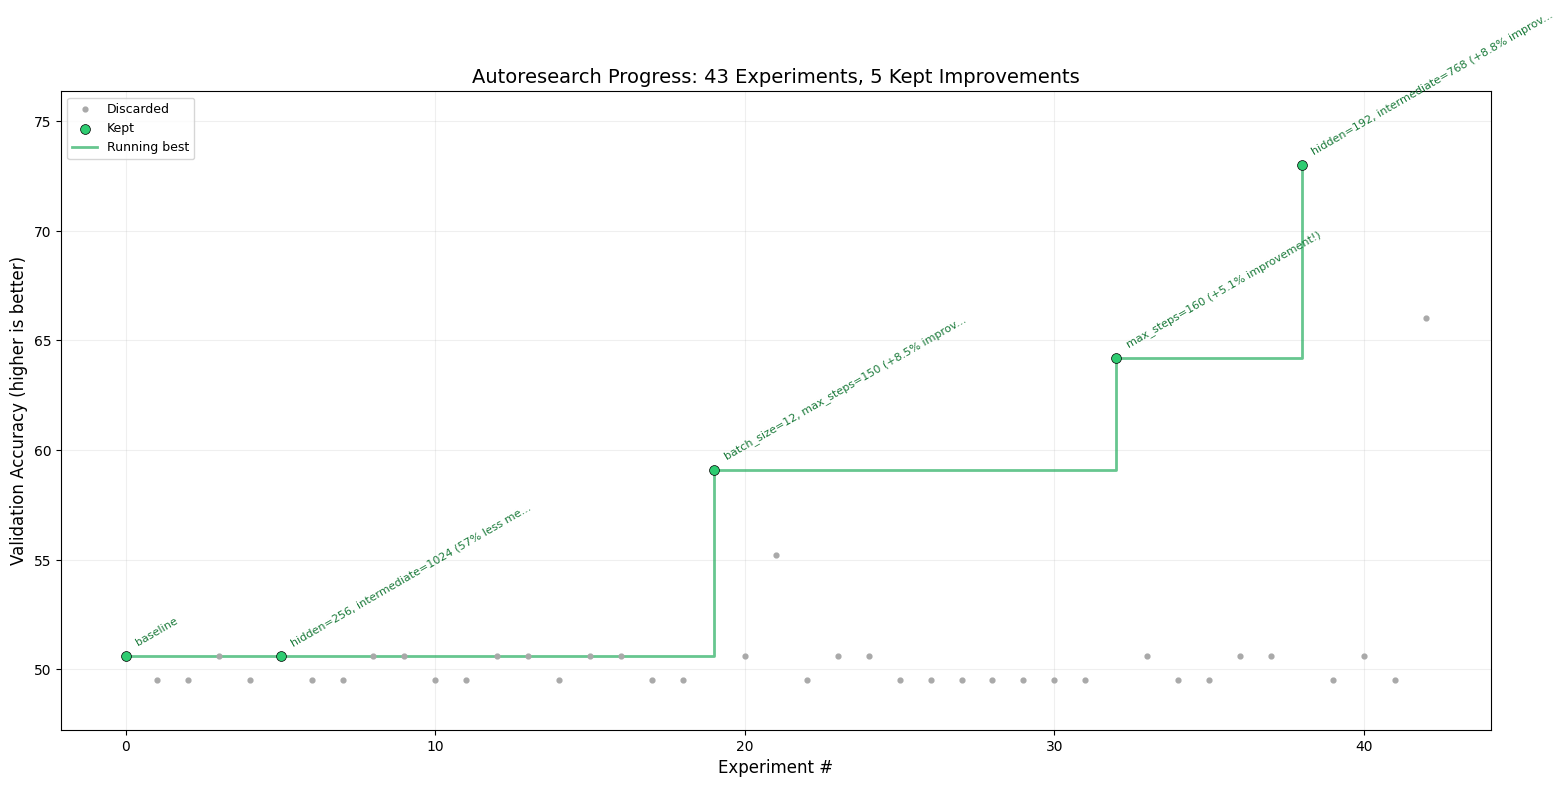

Saved to progress.png
5


In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_acc"]
# print(f"\nBaseline validation BPB: {baseline_bpb:.6f}")
# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_acc"] >= baseline_bpb + 0.0005]
below = valid

print(below)
# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_acc"],
           c="#A9A9A9", s=12, alpha=1, zorder=4, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
print(f"Kept experiments: {kept_v.index}")
ax.scatter(kept_v.index, kept_v["val_acc"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_acc"]
running_min = kept_bpb.cummax()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=1,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation Accuracy (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below worst to just above best
worst_bpb = kept_bpb.min()
best_bpb = kept_bpb.max()
margin = (best_bpb - worst_bpb) * 0.15
if margin == 0:
    margin = 5  # Default margin if all values are the same
ax.set_ylim(worst_bpb - margin, best_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")
print(n_kept)

## Summary Statistics

In [7]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_acc"]
best_bpb = kept["val_acc"].min()
best_row = kept.loc[kept["val_acc"].idxmin()]

print(f"Baseline val_acc:  {baseline_bpb:.6f}")
print(f"Best val_acc:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_acc']:.6f}  {desc}")

Baseline val_acc:  50.600000
Best val_acc:      50.600000
Total improvement: 0.000000 (0.00%)
Best experiment:   baseline

Cumulative effort per improvement:
  Experiment #  0: bpb=50.600000  baseline
  Experiment #  5: bpb=50.600000  hidden=256, intermediate=1024 (57% less memory)
  Experiment # 19: bpb=59.100000  batch_size=12, max_steps=150 (+8.5% improvement!)
  Experiment # 32: bpb=64.200000  max_steps=160 (+5.1% improvement!)
  Experiment # 38: bpb=73.000000  hidden=192, intermediate=768 (+8.8% improvement, 22% less memory!)


## Top Hits (Kept Experiments by Improvement)

In [8]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_acc"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_acc"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_acc']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.000000  50.600000  hidden=256, intermediate=1024 (57% less memory)
   2  -5.100000  64.200000  max_steps=160 (+5.1% improvement!)
   3  -8.500000  59.100000  batch_size=12, max_steps=150 (+8.5% improvement!)
   4  -8.800000  73.000000  hidden=192, intermediate=768 (+8.8% improvement, 22% less memory!)

      -22.400000              TOTAL improvement over baseline
